In [1]:
# Imports y notas rápidas:
# - qml: PennyLane (construcción y ejecución de QNodes)
# - np: NumPy estándar (generación de datos)
# - pnp: PennyLane-compatible NumPy (usar cuando los arrays participen en autodiff)
# - tqdm: barras de progreso para bucles largos
# - train_test_split: dividir dataset en entrenamiento/validación
import pennylane as qml
import numpy as np
from pennylane import numpy as pnp
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import random
import math
import sys
from scipy.stats import truncnorm

In [2]:
from pathlib import Path
import sys

# directorio que contiene model.py
project_root = Path("/home/dayana-henao/Escritorio/DiscriminativeQuantumNeuralNetworks")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# ahora importa el módulo
from model import (
    Circuit, rho1, rho2, loss, get_probabilities,
    get_batches, batch_generator, evaluate_model,
    predict_label, confusion_matrix_inconclusive
)

## Generación de datos (Distribución Normal)

In [3]:
# Generación de datos (Distribución Normal Truncada)
# NOTA: aquí se usa 'random.seed' (módulo de Python) pero las muestras se
# generan con 'np.random.uniform' (NumPy). Para reproducibilidad completa
# se fija también la semilla de NumPy además de la del módulo random.


# Test set
random.seed(2)
np.random.seed(2)
n_test = 10000
data_test = []

def sample_truncated_normal(mean, std, size):
    a, b = (0 - mean) / std, (1 - mean) / std
    return truncnorm(a, b, loc=mean, scale=std).rvs(size)

a_values = sample_truncated_normal(mean=0.25, std=0.05, size=n_test//3)
b_values = sample_truncated_normal(mean=1/np.sqrt(2), std=0.05, size=math.ceil(n_test*(2/3)))

for a in a_values:
    rho, label = rho1(a)
    data_test.append((rho, label))

for b in b_values:
    rho, label = rho2(b)
    data_test.append((rho, label))

# Training / validation 
random.seed(90701)
np.random.seed(90701)
n_samples = 400
data = []

def sample_truncated_normal(mean, std, size):
    a, b = (0 - mean) / std, (1 - mean) / std
    return truncnorm(a, b, loc=mean, scale=std).rvs(size)


a_values = sample_truncated_normal(mean=0.25, std=0.05, size=n_samples//3)
b_values = sample_truncated_normal(mean=1/np.sqrt(2), std=0.05, size=math.ceil(n_samples*(2/3)))

for a in a_values:
    rho, label = rho1(a)
    data.append((rho, label))

for b in b_values:
    rho, label = rho2(b)
    data.append((rho, label))

# Mezclar y dividir: 80% entrenamiento, 20% validación
data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)


## Definir pesos de pérdida

In [4]:
# Pesos de la pérdida: controlar la penalización por errores e inconclusos
# - alpha_err: cuánto penaliza el clasificador un resultado erróneo
# - alpha_inc: cuánto penaliza un resultado inconcluso
alpha_err = 40
alpha_inc = 4

## Entrenamiento del modelo

In [5]:

# Se define el optimizador, número máximo de iteraciones y parámetros de control
# - opt: Adam optimizer de PennyLane (compatibilidad con step_and_cost)
# - n_iter: número máximo de pasos (puede reducirse por early stopping)
opt = qml.AdamOptimizer(stepsize=0.01)
n_iter = 5000
# Batching: asegurarse de al menos 1 y usar RNG reproducible
rng = np.random.default_rng(90701)
batch_size = max(1, int(round(len(data_train) * 0.2)))
val_batch_size = max(1, int(round(0.2 * batch_size)))

initial_params = np.random.uniform(0, 2 * np.pi, 30)
params = pnp.array(initial_params, requires_grad=True)

# Early stopping
patience = 500
min_delta = 1e-4
best_val_loss = float('inf')
patience_counter = 0
best_params = params.copy()  # Guardar los mejores parámetros

# ReduceLROnPlateau
plateau_patience = 150
plateau_factor = 0.5
min_lr = 1e-5
plateau_counter = 0

# Historiales
loss_history = []
val_loss_history = []
train_suc_history = []
train_err_history = []
train_inc_history = []
val_suc_history = []
val_err_history = []
val_inc_history = []

# Generador de batches que recorre el dataset mezclado por epoch
gen = batch_generator(data_train, batch_size, rng)
for it in tqdm(range(n_iter), desc="Entrenando"):

    # Obtener siguiente batch (recorre todo el dataset antes de reshuffle)
    batch = next(gen)

    # Paso de entrenamiento (actualiza parámetros una vez por batch)
    params, train_loss = opt.step_and_cost(lambda v: loss(v, batch, alpha_err, alpha_inc), params)
    val_loss = loss(params, data_val, alpha_err, alpha_inc)

    # EARLY STOPPING 
    if val_loss < best_val_loss - min_delta:  # Mejora significativa
        best_val_loss = val_loss
        best_params = params.copy()  # Guardar mejores parámetros
        patience_counter = 0
        plateau_counter = 0  # reinicia ambos contadores
    else:
        patience_counter += 1
        plateau_counter += 1

    # REDUCE LR ON PLATEAU 
    if plateau_counter >= plateau_patience:
        new_lr = max(opt.stepsize * plateau_factor, min_lr)
        if new_lr < opt.stepsize:
            print(f"Reducción de learning rate: {opt.stepsize:.5f} → {new_lr:.5f}")
            opt.stepsize = new_lr
            plateau_counter = 0  # Reiniciar después de reducir LR

    # STOPPING 
    if patience_counter >= patience:
        print(f"Early stopping en iteración {it+1}. Mejor pérdida de validación: {best_val_loss:.6f}")
        params = best_params  # Restaurar mejores parámetros
        break

    # Evaluación en train, test y validación
    suc_train, err_train, inc_train = evaluate_model(params, data_train)
    suc_val, err_val, inc_val = evaluate_model(params, data_val)


    # Guardar métricas
    loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_suc_history.append(suc_train)
    train_err_history.append(err_train)
    train_inc_history.append(inc_train)
    val_suc_history.append(suc_val)
    val_err_history.append(err_val)
    val_inc_history.append(inc_val)

    if (it + 1) % 50 == 0:
        print(f"Iter {it+1:3d}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
              f"train_suc={suc_train:.3f}, train_err={err_train:.3f}, train_inc={inc_train:.3f} | "
              f"val_suc={suc_val:.3f}, val_err={err_val:.3f}, val_inc={inc_val:.3f}") 
    if (it + 1) % 100 == 0:
        print(f"Iter {it+1}: LR actual = {opt.stepsize:.6f}")

# Usar los mejores parámetros al final
params = best_params

# Final
print("\nParámetros entrenados:")
print(params)

print("\nResultados finales en el conjunto de prueba:")
test_suc, test_err, test_inc = evaluate_model(params, data_test)
print(f"  Éxito promedio     = {test_suc:.4f}")
print(f"  Error promedio     = {test_err:.4f}")
print(f"  Inconcluso promedio = {test_inc:.4f}")

Entrenando:   0%|          | 0/5000 [00:00<?, ?it/s]

Entrenando:   1%|          | 50/5000 [25:53<46:46:31, 34.02s/it]

Iter  50: train_loss=14.6775, val_loss=12.4369, train_suc=0.574, train_err=0.337, train_inc=0.089 | val_suc=0.614, val_err=0.292, val_inc=0.094


Entrenando:   2%|▏         | 100/5000 [51:38<40:54:37, 30.06s/it]

Iter 100: train_loss=9.8895, val_loss=8.6350, train_suc=0.528, train_err=0.213, train_inc=0.258 | val_suc=0.545, val_err=0.177, val_inc=0.278
Iter 100: LR actual = 0.010000


...

Entrenando:  25%|██▌       | 1250/5000 [8:34:08<18:04:11, 17.35s/it]

Iter 1250: train_loss=1.9274, val_loss=1.5371, train_suc=0.636, train_err=0.000, train_inc=0.364 | val_suc=0.694, val_err=0.000, val_inc=0.306


Entrenando:  25%|██▌       | 1250/5000 [8:34:15<25:42:46, 24.68s/it]

Early stopping en iteración 1251. Mejor pérdida de validación: 1.536246

Parámetros entrenados:
[1.2239303  4.71238812 3.83722129 2.20032364 1.57079633 3.14159265
 5.08015756 7.83932869 3.17581344 4.99256211 3.14159265 0.27375243
 3.26562278 4.77715401 1.48284681 5.37317825 5.65607788 4.48997457
 5.58784495 1.57079565 5.09164539 2.2117081  5.80089967 3.35921848
 6.04576058 5.80463408 4.31157517 3.83685804 1.57079723 5.20210974]

Resultados finales en el conjunto de prueba:


  Éxito promedio     = 0.6472
  Error promedio     = 0.0002
  Inconcluso promedio = 0.3525


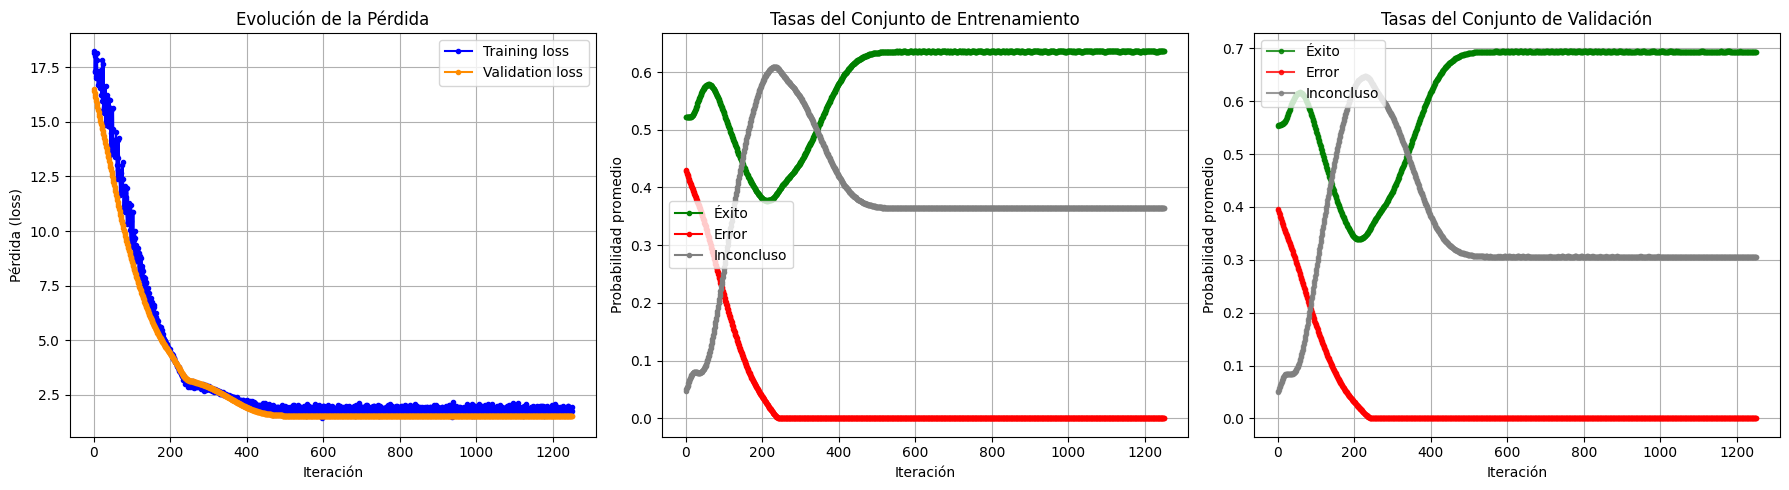

In [6]:
# Visualización de los resultados guardados durante el entrenamiento
# Se muestran: (1) pérdida, (2) tasas en entrenamiento, (3) tasas en validación
it = len(train_suc_history)

# Visualización de los resultados
plt.figure(figsize=(18, 5))

# 1. Evolución de la pérdida
plt.subplot(1, 3, 1)
plt.plot(range(1, it+1), loss_history, '.-', label="Training loss", color='blue')
plt.plot(range(1, it+1), val_loss_history, '.-', label="Validation loss", color='darkorange')
plt.xlabel("Iteración")
plt.ylabel("Pérdida (loss)")
plt.title("Evolución de la Pérdida")
plt.grid(True)
plt.legend()

# 2. Tasas en entrenamiento
plt.subplot(1, 3, 2)
plt.plot(range(1, it+1), train_suc_history, '.-', label="Éxito", color='green')
plt.plot(range(1, it+1), train_err_history, '.-', label="Error", color='red')
plt.plot(range(1, it+1), train_inc_history, '.-', label="Inconcluso", color='gray')
plt.xlabel("Iteración")
plt.ylabel("Probabilidad promedio")
plt.title("Tasas del Conjunto de Entrenamiento")
plt.grid(True)
plt.legend()

# 3. Tasas en validación
plt.subplot(1, 3, 3)
plt.plot(range(1, it+1), val_suc_history, '.-', label="Éxito", color='green', alpha=0.8)
plt.plot(range(1, it+1), val_err_history, '.-', label="Error", color='red', alpha=0.8)
plt.plot(range(1, it+1), val_inc_history, '.-', label="Inconcluso", color='gray', alpha=0.8)
plt.xlabel("Iteración")
plt.ylabel("Probabilidad promedio")
plt.title("Tasas del Conjunto de Validación")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Matriz de confusión

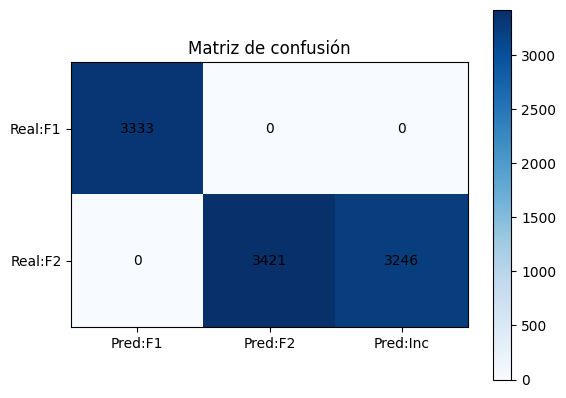

In [7]:
# Construcción y visualización de la matriz de confusión (incluye 'inconcluso')
# La matriz tiene forma 2x3: filas = clases reales (F1,F2), columnas = predicciones (F1,F2,Inc)
cm_test = confusion_matrix_inconclusive(params, data_test)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
im = ax.imshow(cm_test, cmap='Blues', origin='upper')
ax.set_xticks([0,1,2])
ax.set_yticks([0,1])
ax.set_xticklabels(["Pred:F1","Pred:F2","Pred:Inc"])
ax.set_yticklabels(["Real:F1","Real:F2"])
for i in range(2):
    for j in range(3):
        ax.text(j, i, int(cm_test[i,j]), ha='center', va='center', color='black')
plt.colorbar(im, ax=ax)
plt.title('Matriz de confusión')
plt.show()